# 2-stage 3cls classification
- non-osteoporosis vs osteoporosis
- normal vs osteopenia

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix, roc_curve
import seaborn as sns

## JBMR

In [2]:
df = pd.read_csv('/workspace/inference/inference_2stage_jbmr.csv')
df.head()

,인덱스,imgpath,target,stage1:pred,non-porosis:prob,porosis:prob,|,stage2:pred,normal:prob,penia:prob
0,0,/workspace/dataset/3-cls-external/JBMR/osteopo...,2,2,0.155036,0.844964,,NaN,NaN,NaN
1,1,/workspace/dataset/3-cls-external/JBMR/osteopo...,2,2,0.007688,0.992312,,NaN,NaN,NaN
2,2,/workspace/dataset/3-cls-external/JBMR/osteopo...,2,2,0.022375,0.977625,,NaN,NaN,NaN
3,3,/workspace/dataset/3-cls-external/JBMR/osteopo...,2,2,0.000350,0.999650,,NaN,NaN,NaN
4,4,/workspace/dataset/3-cls-external/JBMR/osteopo...,2,0,0.771556,0.228444,,1.0,0.040714,0.959286


### non-osteoporosis vs osteopenia

In [3]:
y_true = df['target']  # 실제 타겟 값
y_prob = df['porosis:prob']  # porosis의 확률
y_pred = df['stage1:pred']

In [4]:
# Calculate the AUC
y_true_bin = (y_true == 2).astype(int)
auc = roc_auc_score(y_true_bin, y_prob)

# Calculate the Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Calculate the F1 Score
y_pred_bin = (y_pred == 2).astype(int)
f1 = f1_score(y_true_bin, y_pred_bin)

# Confusion Matrix
cm = confusion_matrix(y_true_bin, y_pred_bin)

In [5]:
cm # tn, fp, fn, tp

array([[1221,  105],
       [ 180,  483]])

In [6]:
tp_tp = cm.ravel()[-1]

### normal vs osteopenia

In [7]:
y_true = df['target']  # 실제 타겟 값
y_prob1 = df['porosis:prob']  # porosis의 확률
y_prob2 = df['penia:prob']  # penia의 확률
y_pred1 = df['stage1:pred']
y_pred2 = df['stage2:pred']

In [8]:
y_idx2 = y_pred2[~y_pred2.isna()].index
y_true_bin = y_true[y_idx2]
y_true_bin.value_counts()

target
0    674
1    547
2    180
Name: count, dtype: int64

#### 0/1 비교 (penia 모델 tn/fp/fn/tp): 1221

In [9]:
nor = y_true_bin[y_true_bin==0]
y_pred2[nor.index].value_counts()

stage2:pred
0.0    537
1.0    137
Name: count, dtype: int64

In [10]:
pen = y_true_bin[y_true_bin==1]
y_pred2[pen.index].value_counts()

stage2:pred
1.0    468
0.0     79
Name: count, dtype: int64

In [11]:
nor_pen = y_true_bin[y_true_bin!=2]
nor_pen_prob = y_prob2[nor_pen.index]
nor_pen_pred = y_pred2[nor_pen.index]

In [12]:
# Calculate the AUC
auc = roc_auc_score(nor_pen, nor_pen_prob)

# Calculate the Accuracy
accuracy = accuracy_score(nor_pen, nor_pen_pred)

# Calculate the F1 Score
f1 = f1_score(nor_pen, nor_pen_pred)

# Confusion Matrix
cm = confusion_matrix(nor_pen, nor_pen_pred)

In [13]:
tn_tn, tn_fp, tn_fn, tn_tp = cm.ravel()
print(cm)

[[537 137]
 [ 79 468]]


### 0/1을 2로(FP case): 105

In [14]:
y_true_bin = y_true[y_true!=2]

In [15]:
y_pred1[y_true_bin.index].value_counts()

stage1:pred
0    1221
2     105
Name: count, dtype: int64

In [16]:
df[(df['target'].isin([0, 1])) & (df['stage1:pred'] == 2)].target.value_counts()

target
1    105
Name: count, dtype: int64

In [26]:
vc = df[(df['target'].isin([0, 1])) & (df['stage1:pred'] == 2)]['target'].value_counts()
fp_0 = vc.get(0, 0)
fp_1 = vc.get(1, 0)
print(fp_0, fp_1)

0 105


#### 2를 0/1로(FN case):180

In [35]:
print(df[(df['target']==2) & (df['stage2:pred'].isin([0, 1]))]['stage2:pred'].value_counts())

vc = df[(df['target']==2) & (df['stage2:pred'].isin([0, 1]))]['stage2:pred'].value_counts()
fn_0 = vc.get(0, 0)
fn_1 = vc.get(1, 0)
print(fn_0, fn_1)

stage2:pred
1.0    177
0.0      3
Name: count, dtype: int64
3 177


#### Visualize

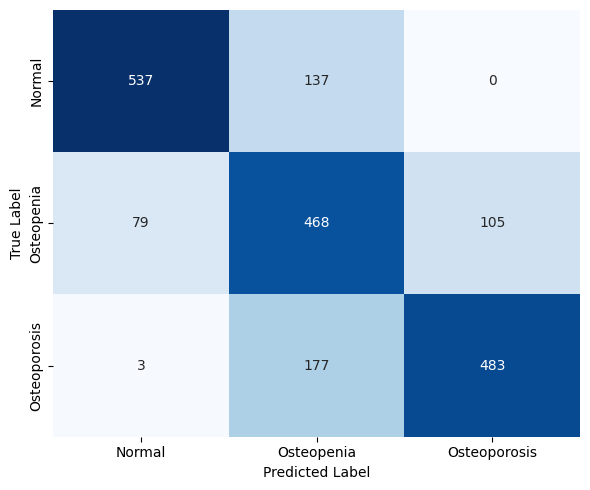

In [36]:
cm1 = np.array([
    [tn_tn, tn_fp, fp_0],
    [tn_fn, tn_tp, fp_1],
    [fn_0,  fn_1, tp_tp]
])
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Osteopenia', 'Osteoporosis'],
            yticklabels=['Normal', 'Osteopenia', 'Osteoporosis'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Asan Cohort

In [37]:
df = pd.read_csv('/workspace/inference/inference_2stage_cohort.csv')
df.head()

,인덱스,imgpath,target,stage1:pred,non-porosis:prob,porosis:prob,|,stage2:pred,normal:prob,penia:prob
0,0,/workspace/dataset/3-cls-external/zzzcase4_coh...,2,0,0.998253,0.001747,,0.0,0.523377,0.476623
1,1,/workspace/dataset/3-cls-external/zzzcase4_coh...,2,0,0.910971,0.089029,,1.0,0.133508,0.866492
2,2,/workspace/dataset/3-cls-external/zzzcase4_coh...,2,2,0.045768,0.954232,,NaN,NaN,NaN
3,3,/workspace/dataset/3-cls-external/zzzcase4_coh...,2,0,0.528111,0.471889,,1.0,0.018556,0.981444
4,4,/workspace/dataset/3-cls-external/zzzcase4_coh...,2,0,0.539991,0.460009,,1.0,0.019943,0.980057


### non-osteoporosis vs osteopenia

In [38]:
y_true = df['target']  # 실제 타겟 값
y_prob = df['porosis:prob']  # porosis의 확률
y_pred = df['stage1:pred']

In [39]:
# Calculate the AUC
y_true_bin = (y_true == 2).astype(int)
auc = roc_auc_score(y_true_bin, y_prob)

# Calculate the Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Calculate the F1 Score
y_pred_bin = (y_pred == 2).astype(int)
f1 = f1_score(y_true_bin, y_pred_bin)

# Confusion Matrix
cm = confusion_matrix(y_true_bin, y_pred_bin)

In [40]:
cm # tn, fp, fn, tp

array([[633, 151],
       [ 68, 237]])

In [41]:
tp_tp = cm.ravel()[-1]

### normal vs osteopenia

In [42]:
y_true = df['target']  # 실제 타겟 값
y_prob1 = df['porosis:prob']  # porosis의 확률
y_prob2 = df['penia:prob']  # penia의 확률
y_pred1 = df['stage1:pred']
y_pred2 = df['stage2:pred']

In [43]:
y_idx2 = y_pred2[~y_pred2.isna()].index
y_true_bin = y_true[y_idx2]
y_true_bin.value_counts()

target
0    389
1    244
2     68
Name: count, dtype: int64

#### 0/1 비교 (penia 모델 tn/fp/fn/tp): 1221

In [44]:
nor = y_true_bin[y_true_bin==0]
y_pred2[nor.index].value_counts()

stage2:pred
0.0    304
1.0     85
Name: count, dtype: int64

In [45]:
pen = y_true_bin[y_true_bin==1]
y_pred2[pen.index].value_counts()

stage2:pred
1.0    212
0.0     32
Name: count, dtype: int64

In [46]:
nor_pen = y_true_bin[y_true_bin!=2]
nor_pen_prob = y_prob2[nor_pen.index]
nor_pen_pred = y_pred2[nor_pen.index]

In [47]:
# Calculate the AUC
auc = roc_auc_score(nor_pen, nor_pen_prob)

# Calculate the Accuracy
accuracy = accuracy_score(nor_pen, nor_pen_pred)

# Calculate the F1 Score
f1 = f1_score(nor_pen, nor_pen_pred)

# Confusion Matrix
cm = confusion_matrix(nor_pen, nor_pen_pred)

In [48]:
tn_tn, tn_fp, tn_fn, tn_tp = cm.ravel()
print(cm)

[[304  85]
 [ 32 212]]


### 0/1을 2로(FP case): 105

In [49]:
y_true_bin = y_true[y_true!=2]

In [50]:
y_pred1[y_true_bin.index].value_counts()

stage1:pred
0    633
2    151
Name: count, dtype: int64

In [51]:
df[(df['target'].isin([0, 1])) & (df['stage1:pred'] == 2)].target.value_counts()

target
1    142
0      9
Name: count, dtype: int64

In [52]:
vc = df[(df['target'].isin([0, 1])) & (df['stage1:pred'] == 2)]['target'].value_counts()
fp_0 = vc.get(0, 0)
fp_1 = vc.get(1, 0)
print(fp_0, fp_1)

9 142


#### 2를 0/1로(FN case):180

In [53]:
print(df[(df['target']==2) & (df['stage2:pred'].isin([0, 1]))]['stage2:pred'].value_counts())

vc = df[(df['target']==2) & (df['stage2:pred'].isin([0, 1]))]['stage2:pred'].value_counts()
fn_0 = vc.get(0, 0)
fn_1 = vc.get(1, 0)
print(fn_0, fn_1)

stage2:pred
1.0    67
0.0     1
Name: count, dtype: int64
1 67


#### Visualize

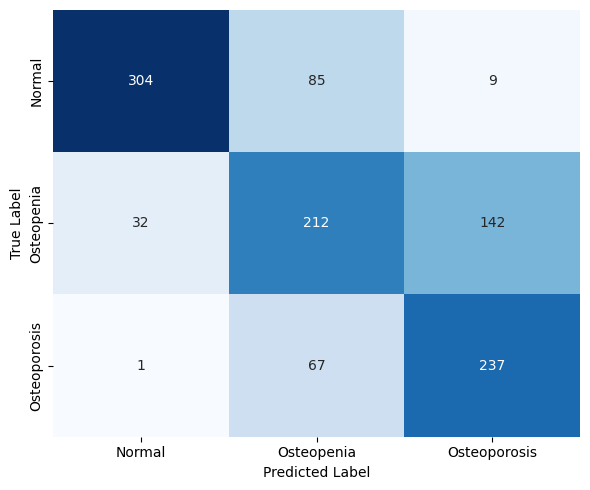

In [54]:
cm1 = np.array([
    [tn_tn, tn_fp, fp_0],
    [tn_fn, tn_tp, fp_1],
    [fn_0,  fn_1, tp_tp]
])
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Osteopenia', 'Osteoporosis'],
            yticklabels=['Normal', 'Osteopenia', 'Osteoporosis'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Chuck

In [55]:
df = pd.read_csv('/workspace/inference/inference_2stage_chuck.csv')
df.head()

,인덱스,imgpath,target,stage1:pred,non-porosis:prob,porosis:prob,|,stage2:pred,normal:prob,penia:prob
0,0,/workspace/dataset/3-cls-external/zzzcase_chuc...,2,2,0.006450,0.993550,,NaN,NaN,NaN
1,1,/workspace/dataset/3-cls-external/zzzcase_chuc...,2,2,0.000203,0.999797,,NaN,NaN,NaN
2,2,/workspace/dataset/3-cls-external/zzzcase_chuc...,2,2,0.008357,0.991643,,NaN,NaN,NaN
3,3,/workspace/dataset/3-cls-external/zzzcase_chuc...,2,2,0.032614,0.967387,,NaN,NaN,NaN
4,4,/workspace/dataset/3-cls-external/zzzcase_chuc...,2,2,0.000062,0.999938,,NaN,NaN,NaN


### non-osteoporosis vs osteopenia

In [56]:
y_true = df['target']  # 실제 타겟 값
y_prob = df['porosis:prob']  # porosis의 확률
y_pred = df['stage1:pred']

In [57]:
# Calculate the AUC
y_true_bin = (y_true == 2).astype(int)
auc = roc_auc_score(y_true_bin, y_prob)

# Calculate the Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Calculate the F1 Score
y_pred_bin = (y_pred == 2).astype(int)
f1 = f1_score(y_true_bin, y_pred_bin)

# Confusion Matrix
cm = confusion_matrix(y_true_bin, y_pred_bin)

In [58]:
cm # tn, fp, fn, tp

array([[2704,  432],
       [  37,  165]])

In [59]:
tp_tp = cm.ravel()[-1]

### normal vs osteopenia

In [60]:
y_true = df['target']  # 실제 타겟 값
y_prob1 = df['porosis:prob']  # porosis의 확률
y_prob2 = df['penia:prob']  # penia의 확률
y_pred1 = df['stage1:pred']
y_pred2 = df['stage2:pred']

In [61]:
y_idx2 = y_pred2[~y_pred2.isna()].index
y_true_bin = y_true[y_idx2]
y_true_bin.value_counts()

target
0    1895
1     809
2      37
Name: count, dtype: int64

#### 0/1 비교 (penia 모델 tn/fp/fn/tp): 1221

In [62]:
nor = y_true_bin[y_true_bin==0]
y_pred2[nor.index].value_counts()

stage2:pred
0.0    1693
1.0     202
Name: count, dtype: int64

In [63]:
pen = y_true_bin[y_true_bin==1]
y_pred2[pen.index].value_counts()

stage2:pred
1.0    450
0.0    359
Name: count, dtype: int64

In [64]:
nor_pen = y_true_bin[y_true_bin!=2]
nor_pen_prob = y_prob2[nor_pen.index]
nor_pen_pred = y_pred2[nor_pen.index]

In [65]:
# Calculate the AUC
auc = roc_auc_score(nor_pen, nor_pen_prob)

# Calculate the Accuracy
accuracy = accuracy_score(nor_pen, nor_pen_pred)

# Calculate the F1 Score
f1 = f1_score(nor_pen, nor_pen_pred)

# Confusion Matrix
cm = confusion_matrix(nor_pen, nor_pen_pred)

In [66]:
tn_tn, tn_fp, tn_fn, tn_tp = cm.ravel()
print(cm)

[[1693  202]
 [ 359  450]]


### 0/1을 2로(FP case): 105

In [67]:
y_true_bin = y_true[y_true!=2]

In [68]:
y_pred1[y_true_bin.index].value_counts()

stage1:pred
0    2704
2     432
Name: count, dtype: int64

In [69]:
df[(df['target'].isin([0, 1])) & (df['stage1:pred'] == 2)].target.value_counts()

target
1    391
0     41
Name: count, dtype: int64

In [70]:
vc = df[(df['target'].isin([0, 1])) & (df['stage1:pred'] == 2)]['target'].value_counts()
fp_0 = vc.get(0, 0)
fp_1 = vc.get(1, 0)
print(fp_0, fp_1)

41 391


#### 2를 0/1로(FN case):180

In [71]:
print(df[(df['target']==2) & (df['stage2:pred'].isin([0, 1]))]['stage2:pred'].value_counts())

vc = df[(df['target']==2) & (df['stage2:pred'].isin([0, 1]))]['stage2:pred'].value_counts()
fn_0 = vc.get(0, 0)
fn_1 = vc.get(1, 0)
print(fn_0, fn_1)

stage2:pred
1.0    33
0.0     4
Name: count, dtype: int64
4 33


#### Visualize

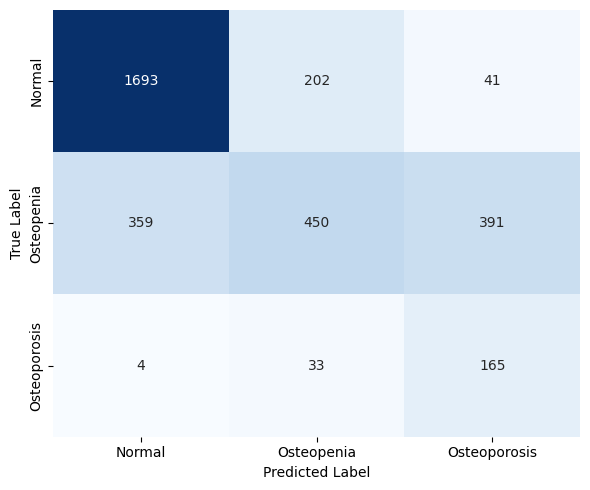

In [72]:
cm1 = np.array([
    [tn_tn, tn_fp, fp_0],
    [tn_fn, tn_tp, fp_1],
    [fn_0,  fn_1, tp_tp]
])
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Osteopenia', 'Osteoporosis'],
            yticklabels=['Normal', 'Osteopenia', 'Osteoporosis'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Bohun

In [73]:
df = pd.read_csv('/workspace/inference/inference_2stage_bohun.csv')
df.head()

,인덱스,imgpath,target,stage1:pred,non-porosis:prob,porosis:prob,|,stage2:pred,normal:prob,penia:prob
0,0,/workspace/dataset/3-cls-external/zzzcase_bohu...,2,2,0.008995,0.991005,,NaN,NaN,NaN
1,1,/workspace/dataset/3-cls-external/zzzcase_bohu...,2,0,0.692444,0.307556,,1.0,0.303388,0.696612
2,2,/workspace/dataset/3-cls-external/zzzcase_bohu...,2,2,0.071535,0.928465,,NaN,NaN,NaN
3,3,/workspace/dataset/3-cls-external/zzzcase_bohu...,2,2,0.000204,0.999796,,NaN,NaN,NaN
4,4,/workspace/dataset/3-cls-external/zzzcase_bohu...,2,2,0.007118,0.992882,,NaN,NaN,NaN


### non-osteoporosis vs osteopenia

In [74]:
y_true = df['target']  # 실제 타겟 값
y_prob = df['porosis:prob']  # porosis의 확률
y_pred = df['stage1:pred']

In [75]:
# Calculate the AUC
y_true_bin = (y_true == 2).astype(int)
auc = roc_auc_score(y_true_bin, y_prob)

# Calculate the Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Calculate the F1 Score
y_pred_bin = (y_pred == 2).astype(int)
f1 = f1_score(y_true_bin, y_pred_bin)

# Confusion Matrix
cm = confusion_matrix(y_true_bin, y_pred_bin)

In [76]:
cm # tn, fp, fn, tp

array([[440, 265],
       [ 13, 220]])

In [77]:
tp_tp = cm.ravel()[-1]

### normal vs osteopenia

In [78]:
y_true = df['target']  # 실제 타겟 값
y_prob1 = df['porosis:prob']  # porosis의 확률
y_prob2 = df['penia:prob']  # penia의 확률
y_pred1 = df['stage1:pred']
y_pred2 = df['stage2:pred']

In [79]:
y_idx2 = y_pred2[~y_pred2.isna()].index
y_true_bin = y_true[y_idx2]
y_true_bin.value_counts()

target
0    240
1    200
2     13
Name: count, dtype: int64

#### 0/1 비교 (penia 모델 tn/fp/fn/tp): 1221

In [80]:
nor = y_true_bin[y_true_bin==0]
y_pred2[nor.index].value_counts()

stage2:pred
0.0    233
1.0      7
Name: count, dtype: int64

In [81]:
pen = y_true_bin[y_true_bin==1]
y_pred2[pen.index].value_counts()

stage2:pred
0.0    170
1.0     30
Name: count, dtype: int64

In [82]:
nor_pen = y_true_bin[y_true_bin!=2]
nor_pen_prob = y_prob2[nor_pen.index]
nor_pen_pred = y_pred2[nor_pen.index]

In [83]:
# Calculate the AUC
auc = roc_auc_score(nor_pen, nor_pen_prob)

# Calculate the Accuracy
accuracy = accuracy_score(nor_pen, nor_pen_pred)

# Calculate the F1 Score
f1 = f1_score(nor_pen, nor_pen_pred)

# Confusion Matrix
cm = confusion_matrix(nor_pen, nor_pen_pred)

In [84]:
tn_tn, tn_fp, tn_fn, tn_tp = cm.ravel()
print(cm)

[[233   7]
 [170  30]]


### 0/1을 2로(FP case): 105

In [85]:
y_true_bin = y_true[y_true!=2]

In [86]:
y_pred1[y_true_bin.index].value_counts()

stage1:pred
0    440
2    265
Name: count, dtype: int64

In [87]:
df[(df['target'].isin([0, 1])) & (df['stage1:pred'] == 2)].target.value_counts()

target
1    233
0     32
Name: count, dtype: int64

In [88]:
vc = df[(df['target'].isin([0, 1])) & (df['stage1:pred'] == 2)]['target'].value_counts()
fp_0 = vc.get(0, 0)
fp_1 = vc.get(1, 0)
print(fp_0, fp_1)

32 233


#### 2를 0/1로(FN case):180

In [89]:
print(df[(df['target']==2) & (df['stage2:pred'].isin([0, 1]))]['stage2:pred'].value_counts())

vc = df[(df['target']==2) & (df['stage2:pred'].isin([0, 1]))]['stage2:pred'].value_counts()
fn_0 = vc.get(0, 0)
fn_1 = vc.get(1, 0)
print(fn_0, fn_1)

stage2:pred
0.0    10
1.0     3
Name: count, dtype: int64
10 3


#### Visualize

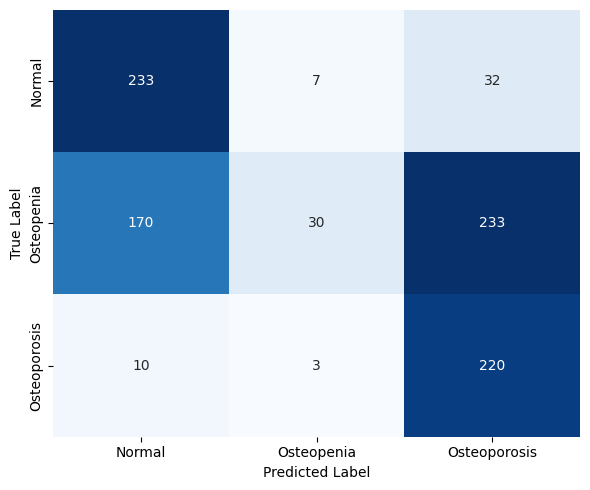

In [90]:
cm1 = np.array([
    [tn_tn, tn_fp, fp_0],
    [tn_fn, tn_tp, fp_1],
    [fn_0,  fn_1, tp_tp]
])
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Osteopenia', 'Osteoporosis'],
            yticklabels=['Normal', 'Osteopenia', 'Osteoporosis'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## GH

In [91]:
df = pd.read_csv('/workspace/inference/inference_2stage_gh.csv')
df.head()

,인덱스,imgpath,target,stage1:pred,non-porosis:prob,porosis:prob,|,stage2:pred,normal:prob,penia:prob
0,0,/workspace/dataset/3-cls-external/GH_FM_3cls/t...,2,2,0.093434,0.906566,,NaN,NaN,NaN
1,1,/workspace/dataset/3-cls-external/GH_FM_3cls/t...,2,2,0.031369,0.968631,,NaN,NaN,NaN
2,2,/workspace/dataset/3-cls-external/GH_FM_3cls/t...,2,0,0.958462,0.041538,,0.0,0.968447,0.031553
3,3,/workspace/dataset/3-cls-external/GH_FM_3cls/t...,2,2,0.011122,0.988878,,NaN,NaN,NaN
4,4,/workspace/dataset/3-cls-external/GH_FM_3cls/t...,2,2,0.154086,0.845914,,NaN,NaN,NaN


### non-osteoporosis vs osteopenia

In [92]:
y_true = df['target']  # 실제 타겟 값
y_prob = df['porosis:prob']  # porosis의 확률
y_pred = df['stage1:pred']

In [93]:
# Calculate the AUC
y_true_bin = (y_true == 2).astype(int)
auc = roc_auc_score(y_true_bin, y_prob)

# Calculate the Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Calculate the F1 Score
y_pred_bin = (y_pred == 2).astype(int)
f1 = f1_score(y_true_bin, y_pred_bin)

# Confusion Matrix
cm = confusion_matrix(y_true_bin, y_pred_bin)

In [94]:
cm # tn, fp, fn, tp

array([[648, 178],
       [ 61, 139]])

In [95]:
tp_tp = cm.ravel()[-1]

### normal vs osteopenia

In [96]:
y_true = df['target']  # 실제 타겟 값
y_prob1 = df['porosis:prob']  # porosis의 확률
y_prob2 = df['penia:prob']  # penia의 확률
y_pred1 = df['stage1:pred']
y_pred2 = df['stage2:pred']

In [97]:
y_idx2 = y_pred2[~y_pred2.isna()].index
y_true_bin = y_true[y_idx2]
y_true_bin.value_counts()

target
1    386
0    262
2     61
Name: count, dtype: int64

#### 0/1 비교 (penia 모델 tn/fp/fn/tp): 1221

In [98]:
nor = y_true_bin[y_true_bin==0]
y_pred2[nor.index].value_counts()

stage2:pred
0.0    251
1.0     11
Name: count, dtype: int64

In [99]:
pen = y_true_bin[y_true_bin==1]
y_pred2[pen.index].value_counts()

stage2:pred
0.0    341
1.0     45
Name: count, dtype: int64

In [100]:
nor_pen = y_true_bin[y_true_bin!=2]
nor_pen_prob = y_prob2[nor_pen.index]
nor_pen_pred = y_pred2[nor_pen.index]

In [101]:
# Calculate the AUC
auc = roc_auc_score(nor_pen, nor_pen_prob)

# Calculate the Accuracy
accuracy = accuracy_score(nor_pen, nor_pen_pred)

# Calculate the F1 Score
f1 = f1_score(nor_pen, nor_pen_pred)

# Confusion Matrix
cm = confusion_matrix(nor_pen, nor_pen_pred)

In [102]:
tn_tn, tn_fp, tn_fn, tn_tp = cm.ravel()
print(cm)

[[251  11]
 [341  45]]


### 0/1을 2로(FP case): 105

In [103]:
y_true_bin = y_true[y_true!=2]

In [104]:
y_pred1[y_true_bin.index].value_counts()

stage1:pred
0    648
2    178
Name: count, dtype: int64

In [105]:
df[(df['target'].isin([0, 1])) & (df['stage1:pred'] == 2)].target.value_counts()

target
1    161
0     17
Name: count, dtype: int64

In [106]:
vc = df[(df['target'].isin([0, 1])) & (df['stage1:pred'] == 2)]['target'].value_counts()
fp_0 = vc.get(0, 0)
fp_1 = vc.get(1, 0)
print(fp_0, fp_1)

17 161


#### 2를 0/1로(FN case):180

In [107]:
print(df[(df['target']==2) & (df['stage2:pred'].isin([0, 1]))]['stage2:pred'].value_counts())

vc = df[(df['target']==2) & (df['stage2:pred'].isin([0, 1]))]['stage2:pred'].value_counts()
fn_0 = vc.get(0, 0)
fn_1 = vc.get(1, 0)
print(fn_0, fn_1)

stage2:pred
0.0    51
1.0    10
Name: count, dtype: int64
51 10


#### Visualize

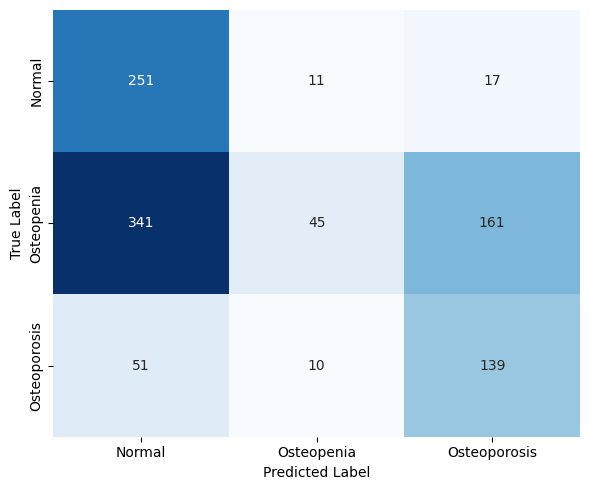

In [108]:
cm1 = np.array([
    [tn_tn, tn_fp, fp_0],
    [tn_fn, tn_tp, fp_1],
    [fn_0,  fn_1, tp_tp]
])
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Osteopenia', 'Osteoporosis'],
            yticklabels=['Normal', 'Osteopenia', 'Osteoporosis'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()